# Analysis

This notebook contains the code for producing the statistical analyses and figures.

In [1]:
import json
import warnings
from collections import defaultdict
from glob import glob

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
import statsmodels.formula.api as smf
import textstat
import wordfreq
from IPython.display import display
from lexical_diversity import lex_div as ld

sns.set_theme()
plt.rcParams["font.family"] = "FreeSans"
plt.rcParams["lines.markersize"] = 4

## Text characteristics

### Loading the generated texts

In [2]:
titles = []
prompts = []
texts = []
gaze_weights = []
token_scores = []
gaze_scores = []
for filename in glob("stories/output-Llama-3B/trf-*-beam8.jsonl"):
    with open(filename) as f:
        for line in f:
            result = json.loads(line)
            titles.append(result["title"])
            prompts.append(result["prompt"])
            texts.append(result["output_text"])
            gaze_weights.append(result["gaze_weight"])
            token_scores.append(result["token_score"])
            gaze_scores.append(result["gaze_score"])
text_df = pd.DataFrame(
    {
        "title": titles,
        "prompt": prompts,
        "text": texts,
        "gaze_weight": gaze_weights,
        "token_score": token_scores,
        "gaze_score": gaze_scores,
    }
)
text_df["total_score"] = text_df["token_score"] + text_df["gaze_weight"] * text_df["gaze_score"]
text_df["prompt_id"] = text_df["title"].map(
    {
        "The Forgotten Message": "voicemail",
        "Breakfast with a Stranger": "breakfast",
        "One Last Wish": "goldfish",
        "Delayed Flight": "delayed",
        "Second Place": "prize",
        "The Last Light On": "blackout",
    }
)
text_df["condition"] = text_df["gaze_weight"].map({2: "pos", -2: "neg", 0: "zero"})
text_df

,title,prompt,text,gaze_weight,token_score,gaze_score,total_score,prompt_id,condition
0,The Forgotten Message,A character finds an old voicemail on their ph...,"I stared blankly at the screen, my thumb hover...",1.0,-124.529366,-26.925503,-151.454868,voicemail,NaN
1,Breakfast with a Stranger,"While eating at a local diner, a character is ...","I slid into the booth, the worn vinyl creaking...",1.0,-163.319962,14.835445,-148.484516,breakfast,NaN
2,One Last Wish,A child claims their elderly pet goldfish gran...,Emma's eyes welled up with tears as she gazed ...,1.0,-174.104767,-4.731176,-178.835943,goldfish,NaN
3,Delayed Flight,"Two strangers, both stuck in an airport during...","As the storm rolled in, the airport's fluoresc...",1.0,-160.814819,18.109713,-142.705107,delayed,NaN
4,Second Place,A lifelong second-place finisher in everything...,"Emma had always been the perpetual bridesmaid,...",1.0,-216.258163,55.777031,-160.481133,prize,NaN
...,...,...,...,...,...,...,...,...,...
61,Breakfast with a Stranger,"While eating at a local diner, a character is ...","As I slid into the booth at the local diner, I...",-2.0,-155.303589,-137.195084,119.086578,breakfast,neg
62,One Last Wish,A child claims their elderly pet goldfish gran...,As the sun set on the small town of Willow Cre...,-2.0,-197.725006,-147.802536,97.880066,goldfish,neg
63,Delayed Flight,"Two strangers, both stuck in an airport during...","As the storm rolled in, the airport was transf...",-2.0,-190.454849,-173.082611,155.710373,delayed,neg
64,Second Place,A lifelong second-place finisher in everything...,"For as long as she could remember, Emma had co...",-2.0,-199.297165,-175.143555,150.989944,prize,neg


### Calculating text statistics

In [3]:
# Process texts with spaCy
nlp = spacy.load("en_core_web_trf")
text_df["spacy_doc"] = text_df["text"].apply(lambda x: nlp(x))

# Map tokens to AOI indices (whitespace-delimited words)
spacy.tokens.Token.set_extension("aoi_index", default=None, force=True)
for _, row in text_df.iterrows():
    i = len(row["title"].split())
    for token in row["spacy_doc"]:
        token._.aoi_index = i
        if token.is_space or token.whitespace_:
            i += 1

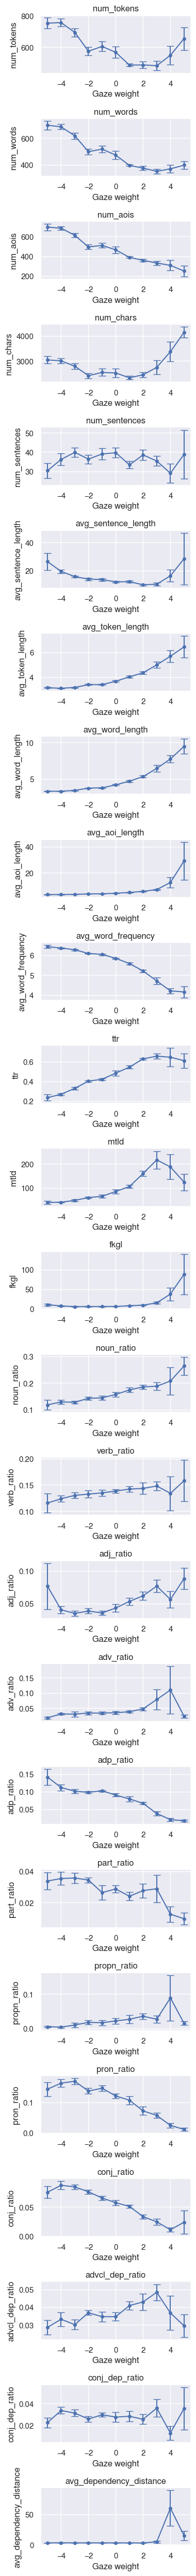

In [4]:
stats = {}

def stat(func):
    stats[func.__name__] = func
    return func

@stat
def num_tokens(doc):
    return len([token for token in doc if token])

@stat
def num_words(doc):
    return len([token for token in doc if not token.is_punct and not token.is_space])

@stat
def num_aois(doc):
    return len(doc.text.split())

@stat
def num_chars(doc):
    return len(doc.text)

@stat
def num_sentences(doc):
    return len(list(doc.sents))

@stat
def avg_sentence_length(doc):
    return num_words(doc) / num_sentences(doc)

@stat
def avg_token_length(doc):
    return sum(len(token) for token in doc) / num_tokens(doc)

@stat
def avg_word_length(doc):
    words = [token for token in doc if not token.is_punct and not token.is_space]
    return sum(len(token) for token in words) / len(words)

@stat
def avg_aoi_length(doc):
    aois = doc.text.split()
    return sum(len(aoi) for aoi in aois) / len(aois)

@stat
def avg_word_frequency(doc):
    words = [token for token in doc if not token.is_punct and not token.is_space]
    return sum(wordfreq.zipf_frequency(token.text, "en") for token in words) / len(words)

@stat
def ttr(doc):
    tokens = ld.tokenize(doc.text)
    return ld.ttr(tokens)

@stat
def mtld(doc):
    tokens = ld.tokenize(doc.text)
    return ld.mtld_ma_wrap(tokens)

@stat
def fkgl(doc):
    return textstat.flesch_kincaid_grade(doc.text)

@stat
def noun_ratio(doc):
    nouns = len([token for token in doc if token.pos_ in {"NOUN"}])
    return nouns / num_tokens(doc)

@stat
def verb_ratio(doc):
    verbs = len([token for token in doc if token.pos_ in {"VERB"}])
    return verbs / num_tokens(doc)

@stat
def adj_ratio(doc):
    adjs = len([token for token in doc if token.pos_ == "ADJ"])
    return adjs / num_tokens(doc)

@stat
def adv_ratio(doc):
    advs = len([token for token in doc if token.pos_ == "ADV"])
    return advs / num_tokens(doc)

@stat
def adp_ratio(doc):
    adps = len([token for token in doc if token.pos_ == "ADP"])
    return adps / num_tokens(doc)

@stat
def part_ratio(doc):
    parts = len([token for token in doc if token.pos_ == "PART"])
    return parts / num_tokens(doc)

@stat
def propn_ratio(doc):
    propns = len([token for token in doc if token.pos_ == "PROPN"])
    return propns / num_tokens(doc)

@stat
def pron_ratio(doc):
    prons = len([token for token in doc if token.pos_ == "PRON"])
    return prons / num_tokens(doc)

@stat
def conj_ratio(doc):
    conjs = len([token for token in doc if token.pos_ in {"CCONJ", "SCONJ"}])
    return conjs / num_tokens(doc)

@stat
def advcl_dep_ratio(doc):
    advcls = len([token for token in doc if token.dep_ == "advcl"])
    return advcls / num_tokens(doc)

@stat
def conj_dep_ratio(doc):
    conjs = len([token for token in doc if token.dep_ == "conj"])
    return conjs / num_tokens(doc)

@stat
def avg_dependency_distance(doc):
    distances = []
    for token in doc:
        if token.head == token:
            continue
        distances.append(abs(token.i - token.head.i))
    return sum(distances) / len(distances)


for name, func in stats.items():
    text_df[name] = text_df["spacy_doc"].apply(func)

stats_df = text_df.groupby("gaze_weight")[list(stats)].aggregate(["mean", "sem"])

fig, axs = plt.subplots(len(stats), 1, figsize=(4, 2 * len(stats)))
for i, (name, func) in enumerate(stats.items()):
    ax = axs[i]
    ax.errorbar(
        stats_df.index,
        stats_df[name]["mean"],
        yerr=stats_df[name]["sem"],
        marker="o",
        capsize=5,
    )
    ax.set_title(name)
    ax.set_xlabel("Gaze weight")
    ax.set_ylabel(name)
fig.tight_layout()

### Plotting text statistics

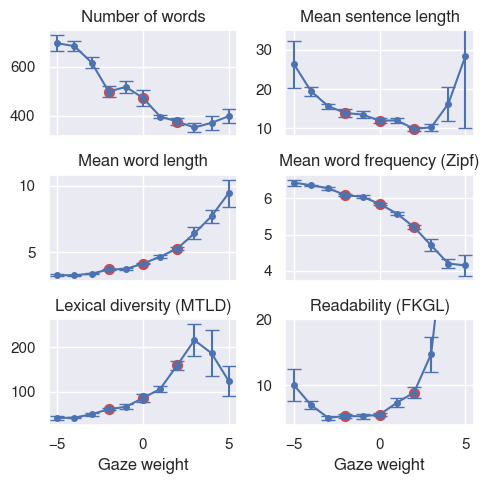

In [5]:
plot_stats = [
    ("num_words", "Number of words", None),
    ("avg_sentence_length", "Mean sentence length", (8, 35)),
    ("avg_word_length", "Mean word length", None),
    ("avg_word_frequency", "Mean word frequency (Zipf)", None),
    ("mtld", "Lexical diversity (MTLD)", None),
    ("fkgl", "Readability (FKGL)", (4, 20)),
]
fig, axs = plt.subplots(3, 2, figsize=(5, 5), sharex=True)
for i, (name, label, ylim) in enumerate(plot_stats):
    ax = axs[i // 2, i % 2]
    ax.errorbar(
        stats_df.index,
        stats_df[name]["mean"],
        yerr=stats_df[name]["sem"],
        marker="o",
        capsize=5,
    )
    stats_highlight_df = stats_df[stats_df.index.isin([-2, 0, 2])]
    ax.scatter(
        stats_highlight_df.index,
        stats_highlight_df[name]["mean"],
        s=50,
        color="C3",
        zorder=1,
        label="Gaze weights used in experiment",
    )
    ax.set_title(label)
    ax.set_ylim(ylim)
    if i // 2 == 2:
        ax.set_xlabel("Gaze weight")

fig.tight_layout()

fig.savefig("paper/figures/text-stats.pdf", bbox_inches="tight")

## Eye-tracking data

### Loading the gaze data

In [6]:
gaze_dfs = []
for filename in glob("eyetracking/*.csv"):
    subject_id = filename.split("/")[-1].split(".")[0]
    gaze = pd.read_csv(filename)
    gaze["subject_id"] = subject_id
    gaze_dfs.append(gaze)
gaze_df = pd.concat(gaze_dfs).reset_index(drop=True)

gaze_df["text_id"] = gaze_df["stimulus"].apply(lambda x: x.split(".")[0])
gaze_df["prompt_id"] = gaze_df["text_id"].apply(lambda x: x.split("-")[0])
gaze_df["condition"] = gaze_df["text_id"].apply(lambda x: x.split("-")[-1])
gaze_df["page"] = gaze_df["stimulus"].apply(lambda x: int(x.split(".")[-1]))
gaze_df["gaze_weight"] = gaze_df["condition"].map({"pos": 2, "neg": -2, "zero": 0})
gaze_df["l1"] = ~gaze_df["subject_id"].isin({f"P{i:02d}" for i in range(1, 13)})

# Add corresponding spacy tokens to AOIs
spacy_tokens = defaultdict(list)
for _, row in text_df.iterrows():
    if pd.notna(row["condition"]):
        for token in row["spacy_doc"]:
            spacy_tokens[(row["prompt_id"], row["condition"], token._.aoi_index)].append(token)

def find_spacy_tokens(row):
    return spacy_tokens[(row["prompt_id"], row["condition"], row["aoi_index"])]

gaze_df["spacy_tokens"] = gaze_df.apply(find_spacy_tokens, axis=1)
gaze_df

,stimulus,aoi_index,aoi_content,fprt,subject_id,text_id,prompt_id,condition,page,gaze_weight,l1,spacy_tokens
0,goldfish-pos.text.0,0,One,0.0,P01,goldfish-pos,goldfish,pos,0,2,False,[]
1,goldfish-pos.text.0,1,Last,360.0,P01,goldfish-pos,goldfish,pos,0,2,False,[]
2,goldfish-pos.text.0,2,Wish,109.0,P01,goldfish-pos,goldfish,pos,0,2,False,[]
3,goldfish-pos.text.0,3,Emma,134.0,P01,goldfish-pos,goldfish,pos,0,2,False,[Emma]
4,goldfish-pos.text.0,4,sat,187.0,P01,goldfish-pos,goldfish,pos,0,2,False,[sat]
...,...,...,...,...,...,...,...,...,...,...,...,...
51788,delayed-zero.text.4,483,had,138.0,P10,delayed-zero,delayed,zero,4,0,False,[had]
51789,delayed-zero.text.4,484,changed,0.0,P10,delayed-zero,delayed,zero,4,0,False,[changed]
51790,delayed-zero.text.4,485,her,139.0,P10,delayed-zero,delayed,zero,4,0,False,[her]
51791,delayed-zero.text.4,486,life,0.0,P10,delayed-zero,delayed,zero,4,0,False,[life]


### Plotting scores and FPRT

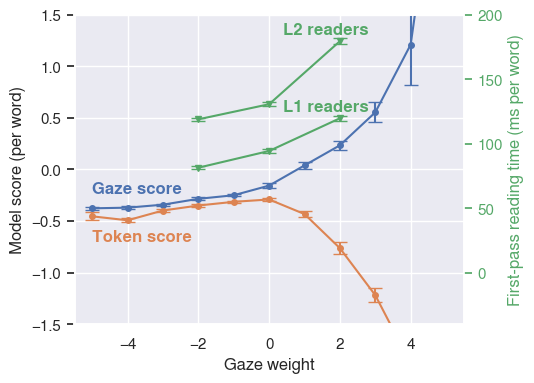

In [7]:
text_df["token_score_per_aoi"] = text_df["token_score"] / text_df["num_aois"]
text_df["gaze_score_per_aoi"] = text_df["gaze_score"] / text_df["num_aois"]
text_df["total_score_per_aoi"] = text_df["total_score"] / text_df["num_aois"]
score_df = text_df.groupby("gaze_weight")[
    ["token_score_per_aoi", "gaze_score_per_aoi", "total_score_per_aoi"]
].aggregate(["mean", "sem"])

fprt_df = gaze_df.groupby("gaze_weight")["fprt"].aggregate(["mean", "sem"])
fprt_l1_df = gaze_df[gaze_df["l1"]].groupby("gaze_weight")["fprt"].aggregate(["mean", "sem"])
fprt_l2_df = gaze_df[~gaze_df["l1"]].groupby("gaze_weight")["fprt"].aggregate(["mean", "sem"])

labels = {
    "token_score_per_aoi": "Token score",
    "gaze_score_per_aoi": "Gaze score",
    "total_score_per_aoi": "Total score",
}

fig, ax = plt.subplots(figsize=(5.5, 4))

gaze_score_plot = ax.errorbar(
    score_df.index,
    score_df["gaze_score_per_aoi"]["mean"],
    yerr=score_df["gaze_score_per_aoi"]["sem"],
    marker="o",
    capsize=5,
)
ax.annotate(
    "Gaze score",
    (score_df.index[0], score_df["gaze_score_per_aoi"]["mean"][0]),
    textcoords="offset points",
    xytext=(0, -5),
    weight="bold",
    color=gaze_score_plot[0].get_color(),
)
token_score_plot = ax.errorbar(
    score_df.index,
    score_df["token_score_per_aoi"]["mean"],
    yerr=score_df["token_score_per_aoi"]["sem"],
    marker="o",
    capsize=5,
)
ax.annotate(
    "Token score",
    (score_df.index[0], score_df["token_score_per_aoi"]["mean"][0]),
    textcoords="offset points",
    xytext=(0, -30),
    weight="bold",
    color=token_score_plot[0].get_color(),
)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("Gaze weight")
ax.set_ylabel("Model score (per word)")

ax2 = ax.twinx()
l2_plot = ax2.errorbar(
    fprt_l2_df.index,
    fprt_l2_df["mean"],
    yerr=fprt_l2_df["sem"],
    marker="v",
    capsize=5,
    color="C2",
)
ax2.annotate(
    "L2 readers",
    (fprt_l2_df.index[2], fprt_l2_df["mean"][2]),
    textcoords="offset points",
    xytext=(-10, 5),
    ha="center",
    weight="bold",
    color=l2_plot[0].get_color(),
)
l1_plot = ax2.errorbar(
    fprt_l1_df.index,
    fprt_l1_df["mean"],
    yerr=fprt_l1_df["sem"],
    marker="v",
    capsize=5,
    color="C2",
)
ax2.annotate(
    "L1 readers",
    (fprt_l1_df.index[2], fprt_l1_df["mean"][2]),
    textcoords="offset points",
    xytext=(-10, 5),
    ha="center",
    weight="bold",
    color=l1_plot[0].get_color(),
)
ax2.set_ylim(-40, 200)
ax2.set_ylabel("First-pass reading time (ms per word)")
ax2.grid(False)
ax2.yaxis.label.set_color(l1_plot[0].get_color())
ax2.tick_params(axis="y", colors=l1_plot[0].get_color())

fig.tight_layout()

fig.savefig("paper/figures/score-fprt.pdf", bbox_inches="tight")

### Linear mixed-effects models

#### Loading prevalence data ([Brysbaert et al., 2018](https://doi.org/10.3758/s13428-018-1077-9))

In [8]:
lexicon_df = pd.read_excel("https://osf.io/download/nbu9e/", index_col="Word")

def avg_lexicon_stat(tokens, stat):
    lexicon = lexicon_df[stat]
    values = []
    for token in tokens:
        if token.text.lower() in lexicon:
            values.append(lexicon[token.text.lower()])
        elif token.lemma_ in lexicon:
            values.append(lexicon[token.lemma_])
    if len(values) == 0:
        return None
    return sum(values) / len(values)

gaze_df["condition"] = pd.Categorical(
    gaze_df["condition"], categories=["zero", "neg", "pos"], ordered=True
)
gaze_df["word_length"] = gaze_df["aoi_content"].apply(len)
gaze_df["word_prevalence"] = gaze_df["spacy_tokens"].apply(avg_lexicon_stat, stat="Prevalence")
gaze_df["word_frequency"] = gaze_df["spacy_tokens"].apply(avg_lexicon_stat, stat="FreqZipfUS")

# Drop AOIs without prevalence info
before = len(gaze_df)
gaze_df = gaze_df[gaze_df["word_prevalence"].notna()]
after = len(gaze_df)
print(f"Dropped {before - after} AOIs ({(before - after) / before:.1%}) without prevalence info")

gaze_df

Dropped 1871 AOIs (3.6%) without prevalence info


,stimulus,aoi_index,aoi_content,fprt,subject_id,text_id,prompt_id,condition,page,gaze_weight,l1,spacy_tokens,word_length,word_prevalence,word_frequency
4,goldfish-pos.text.0,4,sat,187.0,P01,goldfish-pos,goldfish,pos,0,2,False,[sat],3,2.170756,4.456187
5,goldfish-pos.text.0,5,beside,341.0,P01,goldfish-pos,goldfish,pos,0,2,False,[beside],6,2.440700,4.181136
6,goldfish-pos.text.0,6,her,0.0,P01,goldfish-pos,goldfish,pos,0,2,False,[her],3,2.242569,6.452087
7,goldfish-pos.text.0,7,grandmother's,318.0,P01,goldfish-pos,goldfish,pos,0,2,False,"[grandmother, 's]",13,2.422252,4.443510
8,goldfish-pos.text.0,8,hospital,244.0,P01,goldfish-pos,goldfish,pos,0,2,False,[hospital],8,2.432683,5.093581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51788,delayed-zero.text.4,483,had,138.0,P10,delayed-zero,delayed,zero,4,0,False,[had],3,2.312305,6.223663
51789,delayed-zero.text.4,484,changed,0.0,P10,delayed-zero,delayed,zero,4,0,False,[changed],7,2.227334,5.380289
51790,delayed-zero.text.4,485,her,139.0,P10,delayed-zero,delayed,zero,4,0,False,[her],3,2.242569,6.452087
51791,delayed-zero.text.4,486,life,0.0,P10,delayed-zero,delayed,zero,4,0,False,[life],4,2.442037,5.900681


#### Fitting models

In [9]:
gaze_df_l1 = gaze_df[gaze_df["l1"]]
gaze_df_l2 = gaze_df[~gaze_df["l1"]]
mlm_results = {
    group: {
        "gaze": smf.mixedlm(
            "fprt ~ condition",
            data=mlm_data,
            groups=mlm_data["subject_id"],
        ).fit(),
        "baseline": smf.mixedlm(
            "fprt ~ word_length + word_prevalence",
            data=mlm_data,
            groups=mlm_data["subject_id"],
        ).fit(),
        "full": smf.mixedlm(
            "fprt ~ word_length + word_prevalence + condition",
            data=mlm_data,
            groups=mlm_data["subject_id"],
        ).fit(),
    }
    for group, mlm_data in [("L1 readers", gaze_df_l1), ("L2 readers", gaze_df_l2)]
}

#### Results: L1 readers

In [10]:
print("Gaze weight predictors:")
display(mlm_results["L1 readers"]["gaze"].summary())
print("Baseline predictors:")
display(mlm_results["L1 readers"]["baseline"].summary())
print("All predictors:")
display(mlm_results["L1 readers"]["full"].summary())

Gaze weight predictors:


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:              MixedLM  Dependent Variable:  fprt        
No. Observations:   22027    Method:              REML        
No. Groups:         9        Scale:               17970.3535  
Min. group size:    1750     Log-Likelihood:      -139158.7167
Max. group size:    2708     Converged:           Yes         
Mean group size:    2447.4                                    
--------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept         92.636    6.703 13.820 0.000  79.498 105.774
condition[T.neg] -11.239    2.100 -5.353 0.000 -15.355  -7.124
condition[T.pos]  28.720    2.341 12.270 0.000  24.132  33.308
Group Var        383.699    1.457                             
==============================================================

"""

Baseline predictors:


<class 'statsmodels.iolib.summary2.Summary'>
"""
           Mixed Linear Model Regression Results
============================================================
Model:              MixedLM Dependent Variable: fprt        
No. Observations:   22027   Method:             REML        
No. Groups:         9       Scale:              15330.6662  
Min. group size:    1750    Log-Likelihood:     -137411.0399
Max. group size:    2708    Converged:          Yes         
Mean group size:    2447.4                                  
------------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------
Intercept        23.977   11.801  2.032 0.042   0.846 47.107
word_length      21.368    0.337 63.373 0.000  20.707 22.029
word_prevalence -11.050    4.307 -2.565 0.010 -19.491 -2.608
Group Var       402.905    1.655                            
============================================================

"""

All predictors:


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:             MixedLM  Dependent Variable:  fprt        
No. Observations:  22027    Method:              REML        
No. Groups:        9        Scale:               15331.9684  
Min. group size:   1750     Log-Likelihood:      -137407.7675
Max. group size:   2708     Converged:           Yes         
Mean group size:   2447.4                                    
-------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-------------------------------------------------------------
Intercept         24.549   11.899  2.063 0.039   1.227 47.870
condition[T.neg]  -0.421    1.947 -0.216 0.829  -4.238  3.396
condition[T.pos]  -0.830    2.222 -0.373 0.709  -5.186  3.526
word_length       21.394    0.354 60.373 0.000  20.699 22.088
word_prevalence  -11.186    4.330 -2.583 0.010 -19.673 -2.699
Group Var        402.233    1.652                            
=============================================================

"""

#### Results: L2 readers

In [11]:
print("Gaze weight predictors:")
display(mlm_results["L2 readers"]["gaze"].summary())
print("Baseline predictors:")
display(mlm_results["L2 readers"]["baseline"].summary())
print("All predictors:")
display(mlm_results["L2 readers"]["full"].summary())

Gaze weight predictors:


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:              MixedLM  Dependent Variable:  fprt        
No. Observations:   27895    Method:              REML        
No. Groups:         12       Scale:               25769.9550  
Min. group size:    1354     Log-Likelihood:      -181263.6954
Max. group size:    2634     Converged:           Yes         
Mean group size:    2324.6                                    
--------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept        129.869    8.670 14.979 0.000 112.876 146.861
condition[T.neg] -13.437    2.260 -5.946 0.000 -17.866  -9.008
condition[T.pos]  47.725    2.501 19.083 0.000  42.823  52.627
Group Var        869.647    2.333                             
==============================================================

"""

Baseline predictors:


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:             MixedLM  Dependent Variable:  fprt        
No. Observations:  27895    Method:              REML        
No. Groups:        12       Scale:               21577.1315  
Min. group size:   1354     Log-Likelihood:      -178788.6762
Max. group size:   2634     Converged:           Yes         
Mean group size:   2324.6                                    
-------------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept        63.289   13.079  4.839 0.000  37.655  88.924
word_length      27.395    0.352 77.720 0.000  26.704  28.086
word_prevalence -22.310    4.537 -4.918 0.000 -31.202 -13.418
Group Var       791.767    2.323                             
=============================================================

"""

All predictors:


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
==============================================================
Model:              MixedLM  Dependent Variable:  fprt        
No. Observations:   27895    Method:              REML        
No. Groups:         12       Scale:               21567.8211  
Min. group size:    1354     Log-Likelihood:      -178778.3588
Max. group size:    2634     Converged:           Yes         
Mean group size:    2324.6                                    
--------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------
Intercept         59.142   13.191  4.484 0.000  33.289  84.996
condition[T.neg]   0.138    2.076  0.066 0.947  -3.930   4.206
condition[T.pos]   8.056    2.358  3.417 0.001   3.436  12.677
word_length       26.976    0.371 72.642 0.000  26.249  27.704
word_prevalence  -20.569    4.560 -4.511 0.000 -29.505 -11.632
Group Var        795.692    2.335                             
==============================================================

"""

#### Plotting coefficients

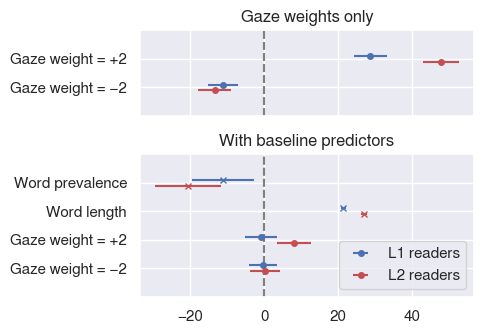

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(5, 3.5), height_ratios=[3, 5], sharex=True)

for key, title, ax in zip(
    ["gaze", "full"],
    ["Gaze weights only", "With baseline predictors"],
    axs,
):
    for group in mlm_results:
        results = mlm_results[group][key]
        k_fe = results.k_fe
        coef = results.params
        ci = results.conf_int(0.05).rename(columns={0: "lower", 1: "upper"})
        covar = results.cov_params()
        se = pd.Series(np.sqrt(np.diag(covar)), index=covar.index)
        z = coef / se
        z_ci = ci.div(se, axis="index")

        coef_labels = {
            "condition[T.neg]": "Gaze weight = −2",
            "condition[T.pos]": "Gaze weight = +2",
            "word_length": "Word length",
            "word_prevalence": "Word prevalence",
        }
        group_colors = {
            "L1 readers": "C0",
            "L2 readers": "C3",
        }
        coef_marker = {
            "condition[T.neg]": "o",
            "condition[T.pos]": "o",
            "word_length": "x",
            "word_prevalence": "x",
        }

        for i, name in enumerate(coef.index[1:k_fe]):
            errorbar = ax.errorbar(
                [coef[name]],
                [i + (0.1 if group == "L1 readers" else -0.1)],
                xerr=[
                    [coef[name] - ci["lower"][name]],
                    [ci["upper"][name] - coef[name]],
                ],
                color=group_colors[group],
                marker=coef_marker[name],
                linestyle="",
                label=group if i == 0 else None,
            )
        ax.axvline(0, color="gray", linestyle="--")
        ax.set_ylim(-1, k_fe - 1)
        ax.set_yticks(range(k_fe - 1))
        ax.set_yticklabels([coef_labels[name] for name in coef.index[1:k_fe]])
        ax.set_title(title)
    if key == "full":
        ax.legend(loc="lower right")

fig.tight_layout()

fig.savefig("paper/figures/model-coef.pdf", bbox_inches="tight")

#### Explained variance

In [13]:
def r2(results, data):
    var_resid = results.scale
    var_random_effect = float(results.cov_re.iloc[0, 0])
    var_fixed_effect = results.predict(data).var()

    total_var = var_fixed_effect + var_random_effect + var_resid
    marginal_r2 = var_fixed_effect / total_var
    conditional_r2 = (var_fixed_effect + var_random_effect) / total_var
    return marginal_r2, conditional_r2

model_keys = ["gaze", "baseline", "full"]
model_descriptions = {
    "gaze": "Only gaze weight",
    "baseline": "Only baseline predictors",
    "full": "All predictors"
}
explained_variances_l1 = [r2(mlm_results["L1 readers"][key], gaze_df_l1)[1] for key in model_descriptions]
explained_variances_l2 = [r2(mlm_results["L2 readers"][key], gaze_df_l2)[1] for key in model_descriptions]
explained_variances_df = pd.DataFrame(
    [
        [model_descriptions[key] for key in model_keys],
        [r2(mlm_results["L1 readers"][key], gaze_df_l1)[1] for key in model_descriptions],
        [r2(mlm_results["L2 readers"][key], gaze_df_l2)[1] for key in model_descriptions],
    ],
    index=["Model", "L1 readers", "L2 readers"],
).T

explained_variances_df

,Model,L1 readers,L2 readers
0,Only gaze weight,0.03412,0.054187
1,Only baseline predictors,0.176923,0.205794
2,All predictors,0.176883,0.206397


## Response data

### Loading the response data

In [14]:
responses_df = pd.read_csv("responses/responses.csv")
responses_df["text_id"] = responses_df["stimulus"].apply(lambda x: x.split(".")[0])
responses_df["prompt_id"] = responses_df["text_id"].apply(lambda x: x.split("-")[0])
responses_df["condition"] = responses_df["text_id"].apply(lambda x: x.split("-")[-1])
responses_df["gaze_weight"] = responses_df["condition"].map({"pos": 2, "neg": -2, "zero": 0})
responses_df["l1"] = ~responses_df["subject_id"].isin({f"P{i:02d}" for i in range(1, 13)})

responses_df

,subject_id,stimulus,question_response,question_correct,difficulty_rating,naturalness_rating,interest_rating,text_id,prompt_id,condition,gaze_weight,l1
0,P01,goldfish-pos,1,1,2,3,4,goldfish-pos,goldfish,pos,2,False
1,P01,breakfast-zero,3,1,2,3,2,breakfast-zero,breakfast,zero,0,False
2,P01,delayed-pos,0,1,1,2,2,delayed-pos,delayed,pos,2,False
3,P01,prize-neg,3,1,1,2,2,prize-neg,prize,neg,-2,False
4,P01,blackout-zero,2,1,2,2,3,blackout-zero,blackout,zero,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
121,P21,voicemail-pos,1,1,2,4,3,voicemail-pos,voicemail,pos,2,True
122,P21,delayed-zero,1,1,2,4,3,delayed-zero,delayed,zero,0,True
123,P21,prize-zero,2,1,1,3,4,prize-zero,prize,zero,0,True
124,P21,goldfish-neg,3,1,1,3,3,goldfish-neg,goldfish,neg,-2,True


### Ratio of correct comprehension responses

In [15]:
responses_df.groupby("subject_id")["question_correct"].mean()

subject_id
P01    1.000000
P02    0.833333
P03    1.000000
P04    1.000000
P05    0.833333
P06    1.000000
P07    0.833333
P08    1.000000
P09    1.000000
P10    1.000000
P11    0.833333
P12    1.000000
P13    0.833333
P14    1.000000
P15    0.833333
P16    0.833333
P17    1.000000
P18    1.000000
P19    1.000000
P20    1.000000
P21    1.000000
Name: question_correct, dtype: float64

In [16]:
float(responses_df["question_correct"].mean())

0.9444444444444444

### Plotting mean ratings

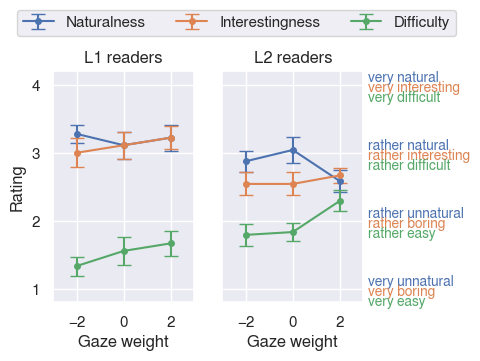

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(4, 3), sharey=True)

for l1, ax in zip([True, False], axs):
    ratings_stats = responses_df[responses_df["l1"] == l1].groupby("gaze_weight")[["difficulty_rating", "naturalness_rating", "interest_rating"]].agg(["mean", "sem"])

    naturalness_color = ax.errorbar(
        ratings_stats.index,
        ratings_stats["naturalness_rating"]["mean"],
        yerr=ratings_stats["naturalness_rating"]["sem"],
        marker="o",
        capsize=5,
        label="Naturalness",
    )[0].get_color()
    interest_color = ax.errorbar(
        ratings_stats.index,
        ratings_stats["interest_rating"]["mean"],
        yerr=ratings_stats["interest_rating"]["sem"],
        marker="o",
        capsize=5,
        label="Interestingness",
    )[0].get_color()
    difficulty_color = ax.errorbar(
        ratings_stats.index,
        ratings_stats["difficulty_rating"]["mean"],
        yerr=ratings_stats["difficulty_rating"]["sem"],
        marker="o",
        capsize=5,
        label="Difficulty",
    )[0].get_color()
    ax.set_xlim(-3, 3)
    ax.set_ylim(0.8, 4.2)
    ax.set_xlabel("Gaze weight")
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels([1, 2, 3, 4])

    if l1:
        ax.set_title("L1 readers")
        ax.set_ylabel("Rating")
    else:
        ax.set_title("L2 readers")
        ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.1, 1.3))

        for i, label in enumerate(["very unnatural", "rather unnatural", "rather natural", "very natural"]):
            ax.annotate(
                label,
                (3.2, i + 1 + 0.15),
                textcoords="offset points",
                xytext=(0, -5),
                color=naturalness_color,
                annotation_clip=False,
                size=10,
            )
        for i, label in enumerate(["very boring", "rather boring", "rather interesting", "very interesting"]):
            ax.annotate(
                label,
                (3.2, i + 1),
                textcoords="offset points",
                xytext=(0, -5),
                color=interest_color,
                annotation_clip=False,
                size=10,
            )
        for i, label in enumerate(["very easy", "rather easy", "rather difficult", "very difficult"]):
            ax.annotate(
                label,
                (3.2, i + 1 - 0.15),
                textcoords="offset points",
                xytext=(0, -5),
                color=difficulty_color,
                annotation_clip=False,
                size=10,
            )

fig.savefig("paper/figures/ratings.pdf", bbox_inches="tight")